##**BITS F464 - Semester 1 - MACHINE LEARNING**
--------------------------------------------------------------------------------

**PROJECT - MACHINE LEARNING FOR SUSTAINABLE DEVELOPMENT GOALS (SDGs)**
--------------------------------------------------------------------------------
***Team number:18***

---
(*In Title case, separated with commas*)
***Full names of all students in the team:Aditya Mahajan,
Paryetri Banerjee,
Drishti Khandor,
 Amit Narayan Satpathy,
 Sriharsha Tippavajhala***

---
(*Separated by commas*)
***Id number of all students in the team:2021A7PS2715H,
2020B1A82001H,
2021A3PS2202H,
2021AAPS2127H,
2021AAPS0717H***


Please refer to the email providing the assignment of project and follow the instructions provided in the project brief.


# **_1. Preprocessing of Dataset_**

### The respective dataset has been shared in the project brief. Please refer to it.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,accuracy_score,confusion_matrix,classification_report

**Importing Dataset at [Data](https://drive.google.com/uc?id=13cJN_K4o2ZwI50pbOHC8tFIYk3AvLmMo)**

In [ ]:
df = pd.read_excel("https://drive.google.com/uc?id=13cJN_K4o2ZwI50pbOHC8tFIYk3AvLmMo")
df.shape

(9357, 15)

Finding types of columns in the Data frame

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           9357 non-null   object
 1   Time           9357 non-null   object
 2   CO(GT)         9357 non-null   object
 3   PT08.S1(CO)    9357 non-null   int64 
 4   NMHC(GT)       9357 non-null   int64 
 5   C6H6(GT)       9357 non-null   object
 6   PT08.S2(NMHC)  9357 non-null   int64 
 7   NOx(GT)        9357 non-null   int64 
 8   PT08.S3(NOx)   9357 non-null   int64 
 9   NO2(GT)        9357 non-null   int64 
 10  PT08.S4(NO2)   9357 non-null   int64 
 11  PT08.S5(O3)    9357 non-null   int64 
 12  T              9357 non-null   object
 13  RH             9357 non-null   object
 14  AH             9357 non-null   int64 
dtypes: int64(9), object(6)
memory usage: 1.1+ MB


In [ ]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-10-03 00:00:00,18.00.00,"2,6",1360,150,"11,9",1046,166,1056,113,1692,1268,"13,6","48,9",7578
1,2004-10-03 00:00:00,19.00.00,2,1292,112,"9,4",955,103,1174,92,1559,972,"13,3","47,7",7255
2,2004-10-03 00:00:00,20.00.00,"2,2",1402,88,"9,0",939,131,1140,114,1555,1074,"11,9","54,0",7502
3,2004-10-03 00:00:00,21.00.00,"2,2",1376,80,"9,2",948,172,1092,122,1584,1203,"11,0","60,0",7867
4,2004-10-03 00:00:00,22.00.00,"1,6",1272,51,"6,5",836,131,1205,116,1490,1110,"11,2","59,6",7888


#Checking the distribution of the Data

In [ ]:
df.describe()

,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,1048.990061,-159.090093,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9846.342524
std,329.832710,139.789093,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,4447.196714
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,921.000000,-200.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,6923.000000
50%,1053.000000,-200.000000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,9768.000000
75%,1221.000000,-200.000000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,12962.000000
max,2040.000000,1189.000000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,22310.000000


# Checking Unique Number of Classes or values

In [ ]:
df.nunique()

Date              391
Time               24
CO(GT)            104
PT08.S1(CO)      1042
NMHC(GT)          430
C6H6(GT)          408
PT08.S2(NMHC)    1246
NOx(GT)           926
PT08.S3(NOx)     1222
NO2(GT)           284
PT08.S4(NO2)     1604
PT08.S5(O3)      1744
T                 437
RH                754
AH               6684
dtype: int64

Loading Labels of all the features

In [ ]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

Replacing all commas with decimal values and replacing all non existent values(-200) with NaN

In [ ]:
# preprocess the data to remove string values
df_numeric = df.drop(columns=['Date','Time'])
import pandas as pd

# Sample DataFrame

# Define a function to convert values
def convert_to_numeric(value):
    if value != "-200":# and value = -200 represents missing values
        return float(str(value).replace(',', '.')) # replace comma with dot
    else:
        return np.nan

Checking all Nullpoints with Heatmap

      CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
0        2.6       1360.0     150.0      11.9         1046.0    166.0   
1        2.0       1292.0     112.0       9.4          955.0    103.0   
2        2.2       1402.0      88.0       9.0          939.0    131.0   
3        2.2       1376.0      80.0       9.2          948.0    172.0   
4        1.6       1272.0      51.0       6.5          836.0    131.0   
...      ...          ...       ...       ...            ...      ...   
9352     3.1       1314.0       NaN      13.5         1101.0    472.0   
9353     2.4       1163.0       NaN      11.4         1027.0    353.0   
9354     2.4       1142.0       NaN      12.4         1063.0    293.0   
9355     2.1       1003.0       NaN       9.5          961.0    235.0   
9356     2.2       1071.0       NaN      11.9         1047.0    265.0   

      PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH      AH  
0           1056.0    113.0        1692.0     

<Axes: >

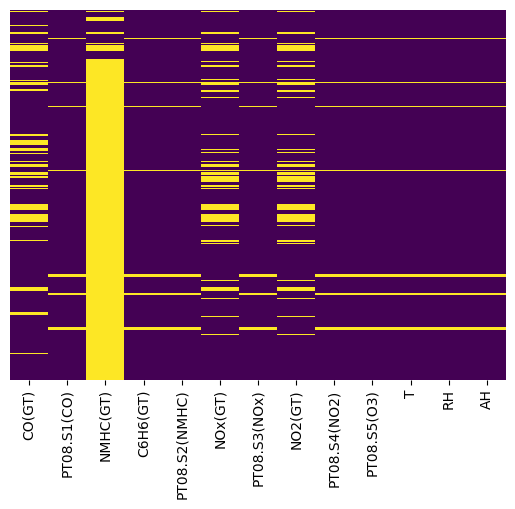

In [ ]:

for column in df_numeric.columns:
    df_numeric[column] = df_numeric[column].apply(convert_to_numeric)
df_numeric = df_numeric[df_numeric != -200]

# Display the updated DataFrame
print(df_numeric)
sns.heatmap(df_numeric.isnull(),yticklabels=False,cbar=False,cmap='viridis')

It can be seen that most of the data in NHMC is Null and can be removed without loss of information

Checking correlation between data it can be seen that PTO8 values have high corelation with their counterparts

In [ ]:

df_numeric = df_numeric.drop(columns=['NMHC(GT)'])
df_numeric.dropna(inplace=True)
print(df_numeric.shape)
corr = df_numeric.corr()

corr.style.background_gradient(cmap='coolwarm')

(6941, 12)


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.000000,0.877014,0.930008,0.914310,0.786456,-0.701038,0.673840,0.630834,0.853480,0.018334,0.064753,0.059346
PT08.S1(CO),0.877014,1.000000,0.877430,0.886068,0.707705,-0.762895,0.628263,0.675910,0.897166,0.028277,0.169234,0.149752
C6H6(GT),0.930008,0.877430,1.000000,0.982705,0.718344,-0.725722,0.603241,0.761805,0.861154,0.189003,-0.021592,0.187072
PT08.S2(NMHC),0.914310,0.886068,0.982705,1.000000,0.705359,-0.781630,0.633310,0.774288,0.876777,0.228333,-0.046084,0.205590
NOx(GT),0.786456,0.707705,0.718344,0.705359,1.000000,-0.662166,0.757029,0.233793,0.788550,-0.275998,0.232255,-0.144186
PT08.S3(NOx),-0.701038,-0.762895,-0.725722,-0.781630,-0.662166,1.000000,-0.641377,-0.511223,-0.793364,-0.099495,-0.116479,-0.223381
NO2(GT),0.673840,0.628263,0.603241,0.633310,0.757029,-0.641377,1.000000,0.142612,0.702524,-0.214325,-0.075333,-0.349646
PT08.S4(NO2),0.630834,0.675910,0.761805,0.774288,0.233793,-0.511223,0.142612,1.000000,0.574242,0.566586,-0.009160,0.646390
PT08.S5(O3),0.853480,0.897166,0.861154,0.876777,0.788550,-0.793364,0.702524,0.574242,1.000000,-0.046146,0.164821,0.075807
T,0.018334,0.028277,0.189003,0.228333,-0.275998,-0.099495,-0.214325,0.566586,-0.046146,1.000000,-0.563909,0.660638


Chercking for Non existent data points

<Axes: >

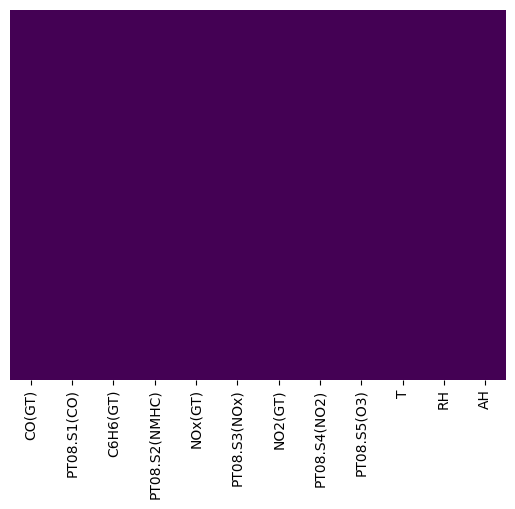

In [ ]:
sns.heatmap(df_numeric.isnull(),yticklabels=False,cbar=False,cmap='viridis')

Calculating an AQI Column to make our predictions based on other columns

In [ ]:
def get_CO_subindex(x):
    if x <= 1:
        return x * 50 / 1
    elif x <= 2:
        return 50 + (x - 1) * 50 / 1
    elif x <= 10:
        return 100 + (x - 2) * 100 / 8
    elif x <= 17:
        return 200 + (x - 10) * 100 / 7
    elif x <= 34:
        return 300 + (x - 17) * 100 / 17
    elif x > 34:
        return 400 + (x - 34) * 100 / 17
    else:
        return 0

def get_NOx_subindex(x):
    if x <= 40:
        return x * 50 / 40
    elif x <= 80:
        return 50 + (x - 40) * 50 / 40
    elif x <= 180:
        return 100 + (x - 80) * 100 / 100
    elif x <= 280:
        return 200 + (x - 180) * 100 / 100
    elif x <= 400:
        return 300 + (x - 280) * 100 / 120
    elif x > 400:
        return 400 + (x - 400) * 100 / 120
    else:
        return 0

def get_NO2_subindex(x):
    if x <= 40:
        return x * 50 / 40
    elif x <= 80:
        return 50 + (x - 40) * 50 / 40
    elif x <= 180:
        return 100 + (x - 80) * 100 / 100
    elif x <= 280:
        return 200 + (x - 180) * 100 / 100
    elif x <= 400:
        return 300 + (x - 280) * 100 / 120
    elif x > 400:
        return 400 + (x - 400) * 100 / 120
    else:
        return 0

# Calculate sub-indices for each pollutant
df_numeric['CO_SubIndex'] = df_numeric['CO(GT)'].apply(get_CO_subindex)
df_numeric['NOx_SubIndex'] = df_numeric['NOx(GT)'].apply(get_NOx_subindex)
df_numeric['NO2_SubIndex'] = df_numeric['NO2(GT)'].apply(get_NO2_subindex)

# Calculate the maximum AQI for each sample
df_numeric['AQI'] = df_numeric[['CO_SubIndex', 'NOx_SubIndex', 'NO2_SubIndex']].max(axis=1)

In [ ]:
print(df_numeric.head())

   CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  \
0     2.6       1360.0      11.9         1046.0    166.0        1056.0   
1     2.0       1292.0       9.4          955.0    103.0        1174.0   
2     2.2       1402.0       9.0          939.0    131.0        1140.0   
3     2.2       1376.0       9.2          948.0    172.0        1092.0   
4     1.6       1272.0       6.5          836.0    131.0        1205.0   

   NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH      AH  CO_SubIndex  \
0    113.0        1692.0       1268.0  13.6  48.9  7578.0        107.5   
1     92.0        1559.0        972.0  13.3  47.7  7255.0        100.0   
2    114.0        1555.0       1074.0  11.9  54.0  7502.0        102.5   
3    122.0        1584.0       1203.0  11.0  60.0  7867.0        102.5   
4    116.0        1490.0       1110.0  11.2  59.6  7888.0         80.0   

   NOx_SubIndex  NO2_SubIndex    AQI  
0         186.0         133.0  186.0  
1         123.0         112.0  1

Checking the linearity between the data. It can be seen AQI is almost linear with respect to all other points

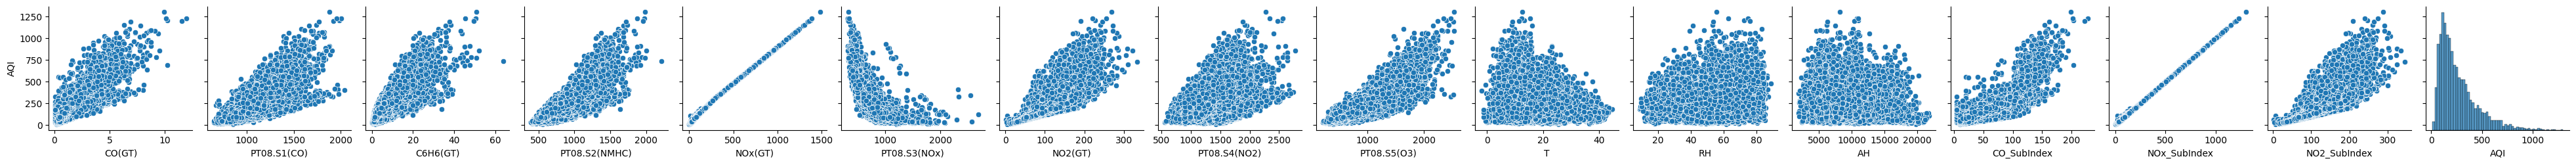

In [ ]:
sns.pairplot(data = df_numeric, y_vars = ['AQI'])

In [ ]:
from sklearn.preprocessing import StandardScaler
def r2_score(y,pred):
    mean_y = np.mean(y)
    ss_tot = sum((y-mean_y)**2)
    ss_res = sum((y-pred)**2)
    r2 = 1 - (ss_res/ss_tot)
    return r2
def mean_squared_error(y,pred):
    mse = np.mean((y-pred)**2)
    return mse
def train_test_split(X,y,test_size=0.2):
    n_samples = X.shape[0]
    test_size = round(n_samples * test_size)
    indices = np.random.permutation(n_samples)
    X_train = X[indices[:-test_size]]
    y_train = y[indices[:-test_size]]
    X_test = X[indices[-test_size:]]
    y_test = y[indices[-test_size:]]
    return X_train,X_test,y_train,y_test

# ***2. ML Model 1:(ANNs\)***

Epoch 0: Loss = 8.286858100159304
Epoch 1000: Loss = 0.08772734633020059
Epoch 2000: Loss = 0.07641103699942504
Epoch 3000: Loss = 0.06978176762914473
Epoch 4000: Loss = 0.06577738711733072
Epoch 5000: Loss = 0.0634052897029886
Epoch 6000: Loss = 0.061949717635483216
Epoch 7000: Loss = 0.060932801720561036
Epoch 8000: Loss = 0.060079558642157554
Epoch 9000: Loss = 0.059309088752377115
Epoch 10000: Loss = 0.05861398590160681
Epoch 11000: Loss = 0.05798652726205528
Epoch 12000: Loss = 0.057409801498376295
Epoch 13000: Loss = 0.05686631663967532
Epoch 14000: Loss = 0.0563455852235537
Epoch 15000: Loss = 0.05584522412675619
Epoch 16000: Loss = 0.0553673763466988
Epoch 17000: Loss = 0.05491476522667696
Epoch 18000: Loss = 0.05448854601602504
Epoch 19000: Loss = 0.05408784139157189
Epoch 20000: Loss = 0.05371013171189547
Epoch 21000: Loss = 0.05335186862889614
Epoch 22000: Loss = 0.053009028327482
Epoch 23000: Loss = 0.052677540375820654
Epoch 24000: Loss = 0.0523536100086752
Epoch 25000: Lo

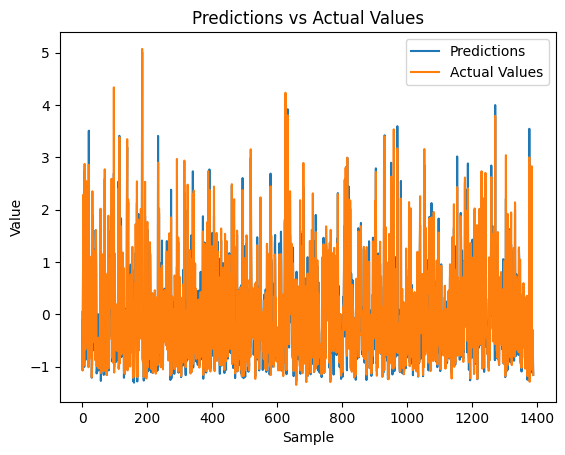

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class ANN:
    def __init__(self,hs1,hs2):
        self.input_size = 9
        self.hidden_size = hs1
        self.hidden_size2 = hs2
        self.output_size = 1
        self.weights1 = np.random.randn(self.input_size, self.hidden_size)
        self.weights2 = np.random.randn(self.hidden_size, self.hidden_size)
        self.weights3 = np.random.randn(self.hidden_size, self.hidden_size2)
        self.weights4 = np.random.randn(self.hidden_size2, self.output_size)
        self.bias1 = np.zeros((1, self.hidden_size))
        self.bias2 = np.zeros((1, self.hidden_size))
        self.bias3 = np.zeros((1, self.hidden_size2))
        self.bias4 = np.zeros((1, self.output_size))

    def forward(self, X):
        self.z1 = np.dot(X, self.weights1) + self.bias1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.weights2) + self.bias2
        self.a2 = self.sigmoid(self.z2)
        self.z3 = np.dot(self.a2, self.weights3) + self.bias3
        self.a3 = self.sigmoid(self.z3)
        self.z4 = np.dot(self.a3, self.weights4) + self.bias4
        return self.z4


    def backward(self, X, y, output, learning_rate=0.0001):
        self.error = y - output
        self.delta_output = self.error
        self.error_hidden = self.delta_output.dot(self.weights4.T)
        self.delta_hidden = self.error_hidden * self.sigmoid_derivative(self.a3)
        self.error_hidden2 = self.delta_hidden.dot(self.weights3.T)
        self.delta_hidden2 = self.error_hidden2 * self.sigmoid_derivative(self.a2)
        self.error_hidden3 = self.delta_hidden2.dot(self.weights2.T)
        self.delta_hidden3 = self.error_hidden3 * self.sigmoid_derivative(self.a1)

        self.weights4 += learning_rate * self.a3.T.dot(self.delta_output)
        self.weights3 += learning_rate * self.a2.T.dot(self.delta_hidden)
        self.weights2 += learning_rate * self.a1.T.dot(self.delta_hidden2)
        self.weights1 += learning_rate * X.T.dot(self.delta_hidden3)

        self.bias4 += learning_rate * np.sum(self.delta_output, axis=0)
        self.bias3 += learning_rate * np.sum(self.delta_hidden, axis=0)
        self.bias2 += learning_rate * np.sum(self.delta_hidden2, axis=0)
        self.bias1 += learning_rate * np.sum(self.delta_hidden3, axis=0)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def train(self, X_train, y_train, epochs):
        for epoch in range(epochs):
            # Forward propagation
            output = self.forward(X_train)

            # Backward propagation
            self.backward(X_train, y_train, output)

            # Print the loss every 100 epochs
            if epoch % 1000 == 0:
                loss = np.mean(np.square(y_train - output))
                print(f"Epoch {epoch}: Loss = {loss}")

        print("Training complete.")

    def predict(self, X, y):
        output = self.forward(X)
        return output


X = df_numeric.drop(columns=['AQI','CO(GT)','NOx(GT)','NO2(GT)','CO_SubIndex','NOx_SubIndex','NO2_SubIndex'])
y = df_numeric['AQI']
X = StandardScaler().fit_transform(X)
y = StandardScaler().fit_transform(y.values.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

y_train = y_train.reshape((y_train.shape[0],1))

# Create an instance of the ANN class
ann = ANN(30,10)

# Train the neural network
ann.train(X_train, y_train, epochs=50000)

predictions_ann = ann.predict(X_test, y_test)

y_train = y_train.reshape((y_train.shape[0],))
predictions_ann = predictions_ann.reshape((predictions_ann.shape[0],))
print(r2_score(y_test,predictions_ann))
y_test_ann = y_test
# Plot predictions vs actual values
plt.plot(predictions_ann, label='Predictions')
plt.plot(y_test, label='Actual Values')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Predictions vs Actual Values')
plt.legend()
plt.show()

# ***3. ML Model 2: (Random Forests)***


Using an Regression type model for predicting AQI

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

import numpy as np

def r2_score(y,pred):
    mean_y = np.mean(y)
    ss_tot = sum((y-mean_y)**2)
    ss_res = sum((y-pred)**2)
    r2 = 1 - (ss_res/ss_tot)
    return r2
def mean_squared_error(y,pred):
    mse = np.mean((y-pred)**2)
    return mse
def train_test_split(X,y,test_size=0.2):
    n_samples = X.shape[0]
    test_size = round(n_samples * test_size)
    indices = np.random.permutation(n_samples)
    X_train = X[indices[:-test_size]]
    y_train = y[indices[:-test_size]]
    X_test = X[indices[-test_size:]]
    y_test = y[indices[-test_size:]]
    return X_train,X_test,y_train,y_test
from sklearn.preprocessing import StandardScaler

class NodeRegression:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None) -> None:
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

class DecisionTreeRegressor:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None) -> None:
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(self.n_features, X.shape[1])
        self.root = self._grow_tree(X, y)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._calculate_leaf_value(y)
            return NodeRegression(value=leaf_value)

        feature_indices = np.random.choice(n_features, self.n_features, replace=False)
        best_feature, best_threshold = self._best_criteria(X, y, feature_indices)
        left_indices, right_indices = self._split(X[:, best_feature], best_threshold)

        left = self._grow_tree(X[left_indices, :], y[left_indices], depth + 1)
        right = self._grow_tree(X[right_indices, :], y[right_indices], depth + 1)

        return NodeRegression(best_feature, best_threshold, left, right)

    def _best_criteria(self, X, y, feature_indices):
        best_gain = -1
        split_index, split_threshold = None, None

        for feature_index in feature_indices:
            X_column = X[:, feature_index]
            thresholds = np.unique(X_column)
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                if gain > best_gain:
                    best_gain = gain
                    split_index = feature_index
                    split_threshold = threshold

        return int(split_index), float(split_threshold)

    def _information_gain(self, y, X_column, split_threshold):
        parent_variance = np.var(y)

        left_indices, right_indices = self._split(X_column, split_threshold)

        if len(left_indices) == 0 or len(right_indices) == 0:
            return 0

        n = len(y)
        n_l, n_r = len(left_indices), len(right_indices)

        variance_l, variance_r = np.var(y[left_indices]), np.var(y[right_indices])

        child_variance = (n_l / n) * variance_l + (n_r / n) * variance_r

        ig = parent_variance - child_variance
        return ig

    def _split(self, X_column, split_threshold):
        left_indices = np.argwhere(X_column <= split_threshold).flatten()
        right_indices = np.argwhere(X_column > split_threshold).flatten()
        return left_indices, right_indices

    def _calculate_leaf_value(self, y):
        return np.mean(y)

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature_index] <= node.threshold:
            return self._traverse_tree(x, node.left)

        return self._traverse_tree(x, node.right)
    def print_tree(self, node=None, spacing=""):
        if node is None:
            node = self.root
        if node.is_leaf_node():
            print(spacing + "Predict", node.value)
            return
        print(spacing + 'X_' + str(node.feature_index) + ' <= ' + str(node.threshold))
        print(spacing + '--> True:')
        self.print_tree(node.left, spacing + "  ")
        print(spacing + '--> False:')
        self.print_tree(node.right, spacing + "  ")

class RandomForest:
    def __init__(self,X,y) -> None:
        self.trees = []
        self.n_trees = 0
        self.X = X
        self.y = y
        self.n_features = None
        self.n_samples = None
        self.feature_indices = []
    def fit(self):
        self.n_samples = self.X.shape[0]
        self.n_features = self.X.shape[1]
        self.feature_indices = np.arange(self.n_features)
        for i in range(10):
            tree = DecisionTreeRegressor()
            X_sample,y_sample = self.bootstrap_sample()
            tree.fit(X_sample,y_sample)
            self.trees.append(tree)
            self.n_trees += 1
    def bootstrap_sample(self):
        indices = np.random.choice(self.n_samples,self.n_samples,replace=True)
        return self.X[indices],self.y[indices]
    def predict(self,X):
        predictions = np.zeros((X.shape[0],self.n_trees))
        for i,tree in enumerate(self.trees):
            predictions[:,i] = tree.predict(X)
        return np.mean(predictions,axis=1)
    def score(self,X,y):
        predictions = self.predict(X)
        return r2_score(y,predictions)
    def plot_feature_importances(self):
        feature_importances = np.mean([tree.feature_importances_ for tree in self.trees],axis=0)
        plt.bar(self.feature_indices,feature_importances)
        plt.xticks(self.feature_indices,self.feature_indices)
        plt.ylabel('Feature Importance')
        plt.xlabel('Feature Index')
        plt.show()
    def mean_squared_error(self,X,y):
        predictions = self.predict(X)
        return mean_squared_error(y,predictions)
    def print_trees(self):
        for i,tree in enumerate(self.trees):
            print("Tree {}".format(i))
            tree.print_tree()
df_rand = df_numeric.copy(deep = True)
X = df_numeric.drop(columns=['AQI','CO(GT)','NOx(GT)','NO2(GT)','CO_SubIndex','NOx_SubIndex','NO2_SubIndex'])
y = df_numeric['AQI']
X = StandardScaler().fit_transform(X)
y = StandardScaler().fit_transform(y.values.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForest(X_train,y_train)
model.fit()
print("R2 Score",model.score(X_test,y_test))
print("MSE = ",model.mean_squared_error(X_test,y_test))

NameError: ignored

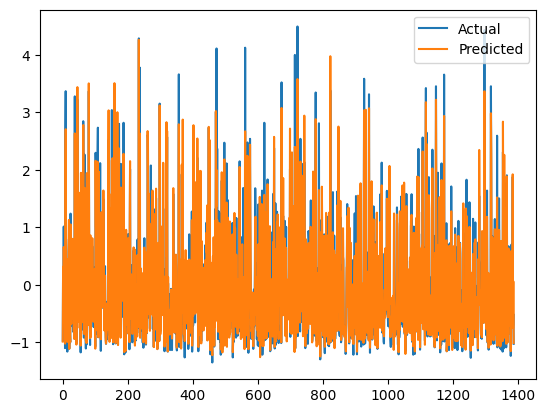

In [ ]:
import matplotlib.pyplot as plt
y_pred_rand = model.predict(X_test)
y_pred_rand = y_pred_rand.reshape(-1,1)
y_test = y_test.reshape(-1,1)
y_test_rand = y_test
plt.plot(y_test,label='Actual')
plt.plot(y_pred_rand,label='Predicted')
plt.legend()
plt.show()

# ***4. ML Model 3: (Bayes Classifier for Continuous Data)***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder  # Added import for LabelEncoder
import pandas as pd
import numpy as np

class GaussianNaiveBayes:
    def __init__(self) -> None:
        self.classes = None
        self.mean = None
        self.var = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = np.zeros((len(self.classes), X.shape[1]))
        self.var = np.zeros((len(self.classes), X.shape[1]))
        for i, c in enumerate(self.classes):  # Fixed variable names here
            X_c = X[y == c]  # Fixed indexing here
            self.mean[i, :] = X_c.mean(axis=0)
            self.var[i, :] = X_c.var(axis=0)

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return y_pred

    def _predict(self, x):
        posteriors = []
        for i, c in enumerate(self.classes):
            prior = np.log(len(X[y == c]) / len(X))  # Fixed prior calculation
            class_conditional = np.sum(np.log(self._pdf(i, x)))
            posterior = prior + class_conditional
            posteriors.append(posterior)
        return self.classes[np.argmax(posteriors)]

    def _pdf(self, class_idx, x):
        # This is the Gaussian Distribution which is used to model the data
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(-(x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

Binning data into columns and using to Naive Bayes Classifier to see the predictions

In [ ]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
labelEncoder = LabelEncoder()
df_bayes = df_numeric.copy(deep = True)
df_bayes["AQI"] = pd.qcut(df_bayes['AQI'], q=4, labels=['Good', 'Moderate', 'Unhealthy','Hazardous'])
df_bayes = df_bayes.drop(columns=['CO(GT)','NOx(GT)','NO2(GT)','CO_SubIndex','NOx_SubIndex','NO2_SubIndex'])
df_bayes['AQI_bin'] = labelEncoder.fit_transform(df_bayes['AQI'])
df_bayes = df_bayes.drop(columns=['AQI'])
X = df_bayes.drop(columns=['AQI_bin'])
y = df_bayes['AQI_bin']
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = GaussianNaiveBayes()
model.fit(X_train,y_train)
y_pred_bayes = model.predict(X_test)
y_test_bayes = y_test
print(accuracy_score(y_test,y_pred_bayes))

NameError: ignored

**Insights of Naive Bayes Classifier**

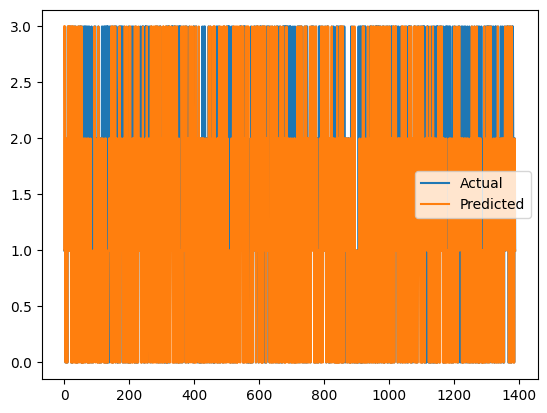

In [ ]:
plt.plot(y_test.to_list(),label = 'Actual')
plt.plot(y_pred_bayes,label='Predicted')
plt.legend()
plt.show()

# ***5. ML Model 4 (Based on research literature)***
# *K Nearest Neighbours*

[[197   0  36   1   1   0]
 [  0 194   0   4   3  23]
 [ 40   0 142   3  45   0]
 [  1   1   8 135  42  42]
 [  1   0  53  46 130   3]
 [  0  26   2  49  11 150]]
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       235
           1       0.88      0.87      0.87       224
           2       0.59      0.62      0.60       230
           3       0.57      0.59      0.58       229
           4       0.56      0.56      0.56       233
           5       0.69      0.63      0.66       238

    accuracy                           0.68      1389
   macro avg       0.68      0.68      0.68      1389
weighted avg       0.68      0.68      0.68      1389



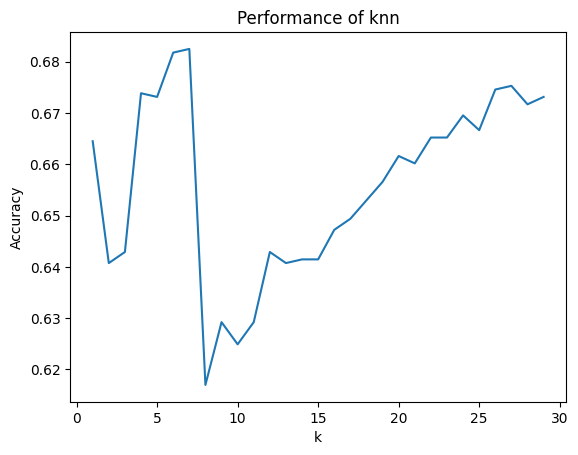

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from collections import Counter
import pandas as pd
import numpy as np

def most_common(lst):
    '''Returns the most common element in a list'''
    return max(set(lst), key=lst.count)

def euclidean(point, data):
    '''Euclidean distance between a point & data'''
    return np.sqrt(np.sum((point - data)**2, axis=1))

class WeightedKNeighborsClassifier():
    def __init__(self, k=7, dist_metric=euclidean):
        self.k = k
        self.dist_metric = dist_metric

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        neighbors = []
        for x in X_test:
            distances = self.dist_metric(x, self.X_train)
            y_sorted = [y for _, y in sorted(zip(distances, self.y_train))]
            neighbors.append(y_sorted[:self.k])

        weighted_predictions = []
        for neighbor_set in neighbors:
            unique_neighbors = list(set(neighbor_set))  # Convert set to list
            weighted_votes = [sum(1 / (distances[i] + 1e-6) for i, y in enumerate(neighbor_set) if y == neighbor) for neighbor in unique_neighbors]
            predicted_label = unique_neighbors[np.argmax(weighted_votes)]
            weighted_predictions.append(predicted_label)

        return weighted_predictions

    def evaluate(self, X_test, y_test):
        y_pred = self.predict(X_test)
        accuracy = sum(np.array(y_pred) == np.array(y_test)) / len(y_test)
        return accuracy




def main():

    df_knn = df_numeric.copy(deep = True)

    # Imputing missing values
    imputer = SimpleImputer(strategy='mean')
    df_knn_imputed = pd.DataFrame(imputer.fit_transform(df_knn), columns=df_knn.columns)

    df_knn_imputed["AQI"] = pd.qcut(df_knn_imputed['AQI'], q=6, labels=['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous'])
    df_knn_imputed = df_knn_imputed.drop(columns=['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'CO_SubIndex', 'NOx_SubIndex', 'NO2_SubIndex'])

    labelEncoder = LabelEncoder()
    df_knn_imputed['AQI_bin'] = labelEncoder.fit_transform(df_knn_imputed['AQI'])
    df_knn_imputed = df_knn_imputed.drop(columns=['AQI'])

    # Separating features (X) and target variable (y)
    X = df_knn_imputed.drop(columns=['AQI_bin'])
    y = df_knn_imputed['AQI_bin']

    # Scaling
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Train-test splitting
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    model = WeightedKNeighborsClassifier()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y = y.astype(int)


    print (confusion_matrix(y_test,y_pred))
    print(classification_report(y_test, y_pred))

    accuracies = []
    ks = range(1, 30)
    for k in ks:
      knn = WeightedKNeighborsClassifier(k=k)
      knn.fit(X_train, y_train)
      accuracy = knn.evaluate(X_test, y_test)
      accuracies.append(accuracy)
    # Visualize accuracy vs. k
    fig, ax = plt.subplots()
    ax.plot(ks, accuracies)
    ax.set(xlabel="k",
       ylabel="Accuracy",
       title="Performance of knn")
    plt.show()

if __name__ == '__main__':
    main()

Performance of KNN:
We see the accuracy comes out to be the highest( almost 70 %) for our dataset when 7 neighbours are chosen (k=7).

**Variable Auto Regression**

> Literature Research Model




In [ ]:
import numpy as np
import pandas as pd

class VAR:
    def __init__(self, p):
        self.p = p
        self.coefficients = None

    def fit(self, data):
        n = len(data)
        k = data.shape[1]
        X = np.zeros((n - self.p, self.p * k))
        y = np.zeros((n - self.p, k))

        for i in range(self.p, n):
            X[i - self.p] = data[i - self.p:i].flatten()
            y[i - self.p] = data[i]

        self.coefficients = np.linalg.lstsq(X, y, rcond=None)[0]

    def predict(self, data):
        n = len(data)
        k = data.shape[1]
        predictions = np.zeros((n, k))

        for i in range(self.p, n):
            X = data[i - self.p:i].flatten()
            predictions[i] = np.dot(X, self.coefficients)

        return predictions
df_var = df_numeric.copy(deep=True)
Xd = df_var.drop(columns=['AQI','CO_SubIndex','NOx_SubIndex','NO2_SubIndex'])
X = Xd.values


var_model = VAR(p=10)

# Step 3: Fit VAR model to sample data
var_model.fit(X)

predictions = var_model.predict(X)

for i in range(X.shape[1]):
    rmse = np.sqrt(mean_squared_error(X[:, i], predictions[:, i]))
    print(f"RMSE for variable {i+1}: {rmse}","(",Xd.columns[i],")")

Avg = np.mean(Xd,axis =0)
inv = [1/x for x in Avg ]
np.multiply(inv,rmse)
print("Average RMSE:",np.mean(rmse))


RMSE for variable 1: 0.6464503208306093 ( CO(GT) )
RMSE for variable 2: 100.54105379893164 ( PT08.S1(CO) )
RMSE for variable 3: 3.4239108018396935 ( C6H6(GT) )
RMSE for variable 4: 115.1302744382379 ( PT08.S2(NMHC) )
RMSE for variable 5: 79.11409823243706 ( NOx(GT) )
RMSE for variable 6: 109.88433569398332 ( PT08.S3(NOx) )
RMSE for variable 7: 18.19674824019578 ( NO2(GT) )
RMSE for variable 8: 131.51318317032636 ( PT08.S4(NO2) )
RMSE for variable 9: 155.5841017316389 ( PT08.S5(O3) )
RMSE for variable 10: 1.174021957062689 ( T )
RMSE for variable 11: 4.596410389194808 ( RH )
RMSE for variable 12: 584.5361631025156 ( AH )
Average RMSE: 584.5361631025156


 This indicates that these variables can be good inputs to judge the quality of air at a given instant in time based on historical data.

*XGBOOST*

In [ ]:


from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

import numpy as np

def r2_score(y,pred):
    mean_y = np.mean(y)
    ss_tot = sum((y-mean_y)**2)
    ss_res = sum((y-pred)**2)
    r2 = 1 - (ss_res/ss_tot)
    return r2
def mean_squared_error(y,pred):
    mse = np.mean((y-pred)**2)
    return mse
def train_test_split(X,y,test_size=0.2):
    n_samples = X.shape[0]
    test_size = round(n_samples * test_size)
    indices = np.random.permutation(n_samples)
    X_train = X[indices[:-test_size]]
    y_train = y[indices[:-test_size]]
    X_test = X[indices[-test_size:]]
    y_test = y[indices[-test_size:]]
    return X_train,X_test,y_train,y_test
from sklearn.preprocessing import StandardScaler

class NodeRegression:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None) -> None:
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

class DecisionTreeRegressor:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None) -> None:
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(self.n_features, X.shape[1])
        self.root = self._grow_tree(X, y)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._calculate_leaf_value(y)
            return NodeRegression(value=leaf_value)

        feature_indices = np.random.choice(n_features, self.n_features, replace=False)
        best_feature, best_threshold = self._best_criteria(X, y, feature_indices)
        left_indices, right_indices = self._split(X[:, best_feature], best_threshold)

        left = self._grow_tree(X[left_indices, :], y[left_indices], depth + 1)
        right = self._grow_tree(X[right_indices, :], y[right_indices], depth + 1)

        return NodeRegression(best_feature, best_threshold, left, right)

    def _best_criteria(self, X, y, feature_indices):
        best_gain = -1
        split_index, split_threshold = None, None

        for feature_index in feature_indices:
            X_column = X[:, feature_index]
            thresholds = np.unique(X_column)
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                if gain > best_gain:
                    best_gain = gain
                    split_index = feature_index
                    split_threshold = threshold

        return int(split_index), float(split_threshold)

    def _information_gain(self, y, X_column, split_threshold):
        parent_variance = np.var(y)

        left_indices, right_indices = self._split(X_column, split_threshold)

        if len(left_indices) == 0 or len(right_indices) == 0:
            return 0

        n = len(y)
        n_l, n_r = len(left_indices), len(right_indices)

        variance_l, variance_r = np.var(y[left_indices]), np.var(y[right_indices])

        child_variance = (n_l / n) * variance_l + (n_r / n) * variance_r

        ig = parent_variance - child_variance
        return ig

    def _split(self, X_column, split_threshold):
        left_indices = np.argwhere(X_column <= split_threshold).flatten()
        right_indices = np.argwhere(X_column > split_threshold).flatten()
        return left_indices, right_indices

    def _calculate_leaf_value(self, y):
        return np.mean(y)

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature_index] <= node.threshold:
            return self._traverse_tree(x, node.left)

        return self._traverse_tree(x, node.right)
    def print_tree(self, node=None, spacing=""):
        if node is None:
            node = self.root
        if node.is_leaf_node():
            print(spacing + "Predict", node.value)
            return
        print(spacing + 'X_' + str(node.feature_index) + ' <= ' + str(node.threshold))
        print(spacing + '--> True:')
        self.print_tree(node.left, spacing + "  ")
        print(spacing + '--> False:')
        self.print_tree(node.right, spacing + "  ")

import numpy as np
from sklearn.preprocessing import StandardScaler

class SquareLoss:
    def gradient(self, y, y_pred):
        return y - y_pred

class XGBoost:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.trees = []
        self.loss = SquareLoss()

    def fit(self, X, y):
        y_pred = np.full(np.shape(y), np.mean(y, axis=0))
        for _ in range(self.n_estimators):
            gradient = self.loss.gradient(y, y_pred)
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, gradient)
            update_pred = self.learning_rate * tree.predict(X)
            y_pred += update_pred
            self.trees.append(tree)

    def predict(self, X):
        y_pred = np.sum([self.learning_rate * tree.predict(X) for tree in self.trees], axis=0)
        return y_pred

    def score(self, X, y):
        y_pred = self.predict(X)
        return r2_score(y, y_pred)

    def mean_squared_error(self, X, y):
        y_pred = self.predict(X)
        return mean_squared_error(y, y_pred)


X = df_numeric.drop(columns=['AQI','CO(GT)','NOx(GT)','NO2(GT)','CO_SubIndex','NOx_SubIndex','NO2_SubIndex'])
y = df_numeric['AQI']
X = StandardScaler().fit_transform(X)
y = StandardScaler().fit_transform(y.values.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = XGBoost(n_estimators=100, learning_rate=0.2, max_depth=3)
model.fit(X_train,y_train)
print("R2 Score",model.score(X_test,y_test))
print("MSE = ",model.mean_squared_error(X_test,y_test))


R2 Score 0.9153557542813822
MSE =  0.08576624042733387


# ***6. Comparison of insights drawn from the models***

ANN - R2 Score: 0.9338839877162872


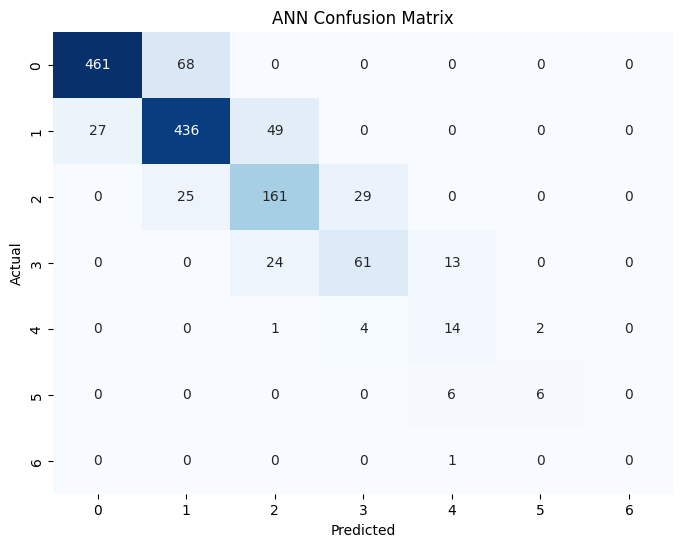

ANN - R2 Score: [0.91527698]


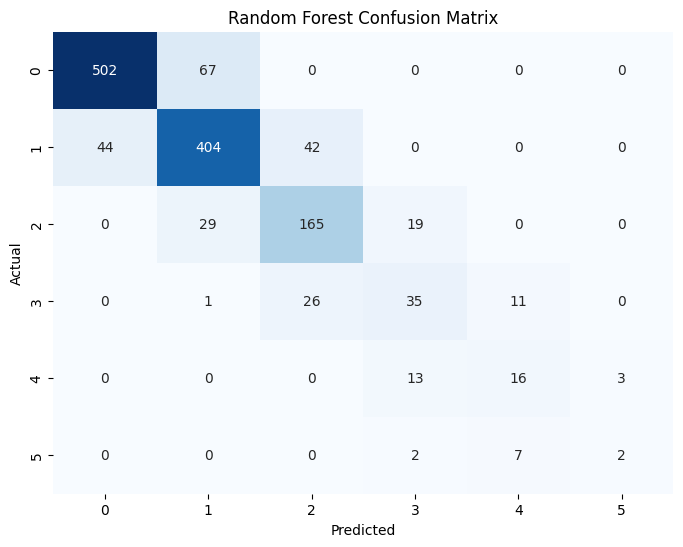

Naive Bayes - Accuracy: 0.5745140388768899


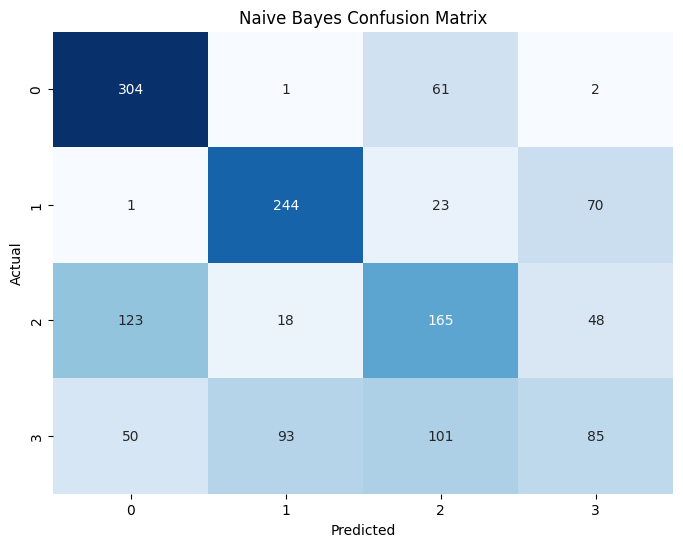

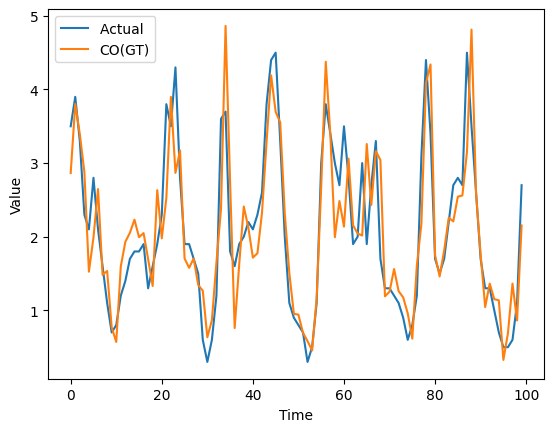

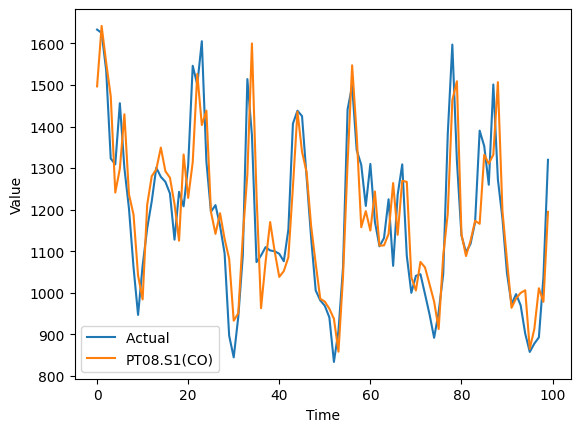

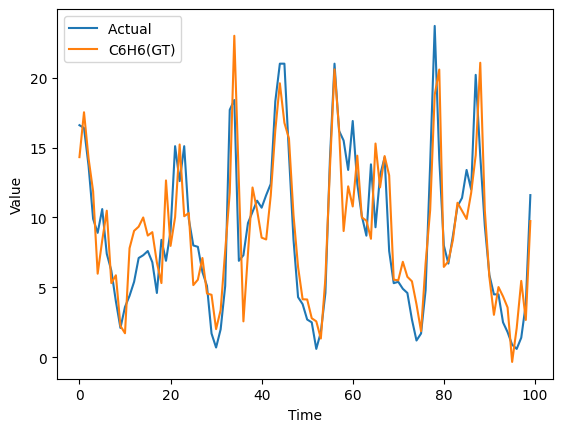

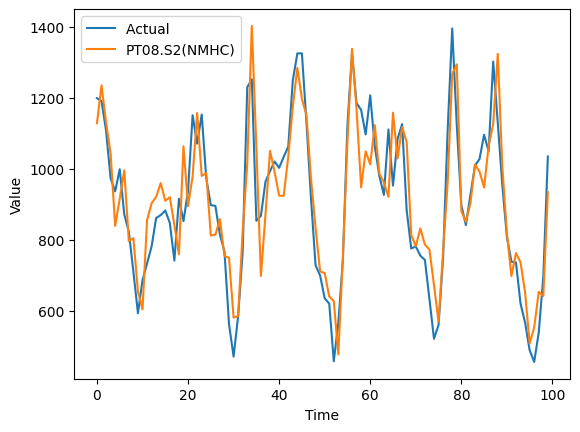

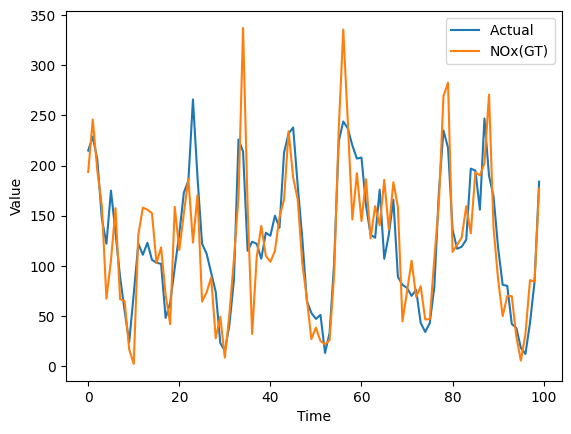

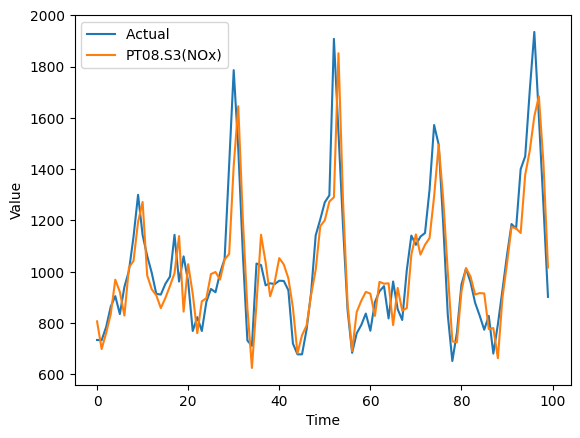

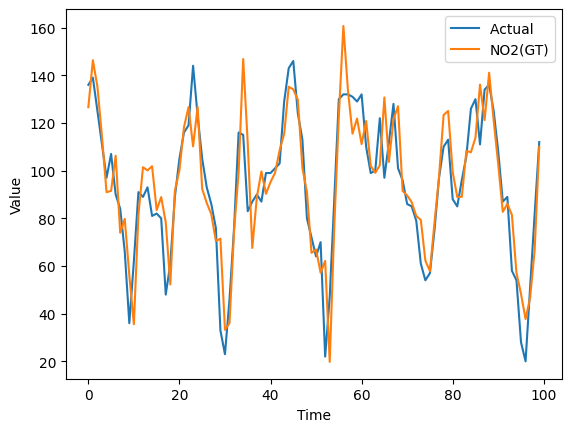

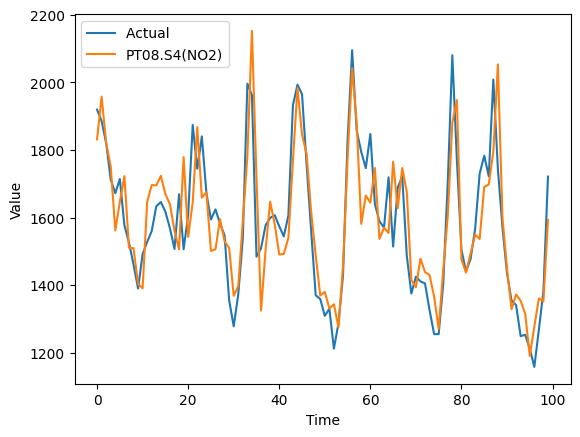

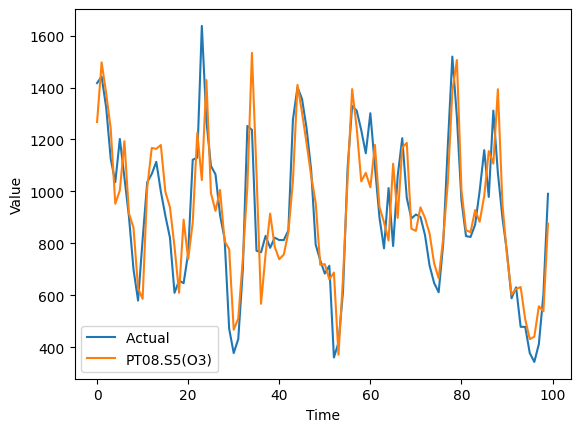

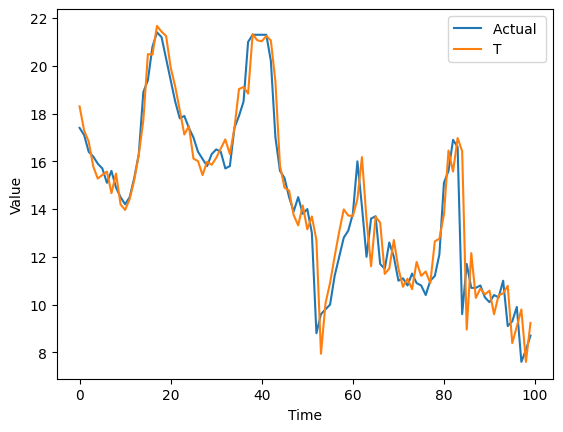

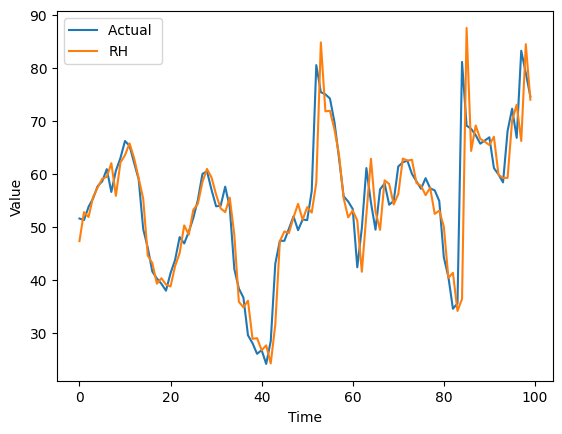

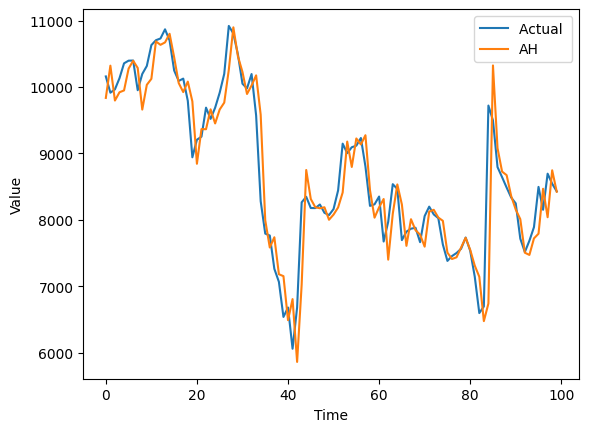

In [ ]:
# Import necessary libraries
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define functions for plotting confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()



print("ANN - R2 Score:", r2_score(y_test_ann, predictions_ann))
plot_confusion_matrix(y_test_ann.round(), predictions_ann.round(), title='ANN Confusion Matrix')

print("ANN - R2 Score:", r2_score(y_test_rand, y_pred_rand))
plot_confusion_matrix(y_test_rand.round(), y_pred_rand.round(), title='Random Forest Confusion Matrix')

print("Naive Bayes - Accuracy:", accuracy_score(y_test_bayes, y_pred_bayes))
plot_confusion_matrix(y_test_bayes, y_pred_bayes, title='Naive Bayes Confusion Matrix')

Xd = df_numeric.drop(columns=['AQI','CO_SubIndex','NOx_SubIndex','NO2_SubIndex'])
y = df_numeric['AQI']
X = Xd.values

predictions = var_model.predict(X)

for i in range(X.shape[1]):
    plt.plot(X[220:320, i], label=f"Actual ")
    plt.plot(predictions[220:320, i], label=f"{Xd.columns[i]}")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(f"")
    plt.legend()
    plt.show()



Confusion matrix for ANN:
We notice that the ratio of the correct classifications as a particular class to misclassification goes on increasing from class(bin) 0 to bin 6. This can be noticed by a decrease in the value of the diagonal elements from class 0 to 6 compared to the other values in the rows representing misclassifications. For example, the correct classifications for class 0 are 461 while misclassifications are 27. The same for class 2 is 161 and (49+24)=73.

Confusion matrix for Random Forests:
We notice that the ratio of the correct classifications as a particular class to misclassification goes on increasing from class(bin) 0 to bin 5. This can be noticed by a decrease in the value of the diagonal elements from class 0 to 5 compared to the other values in the rows representing misclassifications. For example, the correct classifications for class 0 are 502 while misclassifications are 44. The same for class 2 is 165 and (42+26)=68.


Confusion matrix for Naïve Bayes:
We notice that the ratio of the correct classifications as a particular class to misclassification is higher for class 0 and 1. There is a decrease the value of the diagonal elements for class 2 and 3 compared to the other values in the rows representing misclassifications. For example, the correct classifications for class 0 are 304 while misclassifications are 174. The same for class 2 is 165 and 185.

VAR:
For each pollutant the actual and predicted values tend to closely follow each other with some deviation at certain points.


# **_7. References_**

1.  [Random Forests](https://carbonati.github.io/posts/random-forests-from-scratch/)
2.   [Naive Bayes](https://machinelearningmastery.com/naive-bayes-classifier-scratch-python/)
3. [Random Forest with Regression](https://medium.com/@theclickreader/random-forest-regression-explained-with-implementation-in-python-3dad88caf165)
4.[kNN](https://towardsdatascience.com/create-your-own-k-nearest-neighbors-algorithm-in-python-eb7093fc6339)
5.[XGBOOST](https://www.geeksforgeeks.org/xgboost/)
6.[VAR](https://www.kaggle.com/code/ujoshi076/multivariate-time-series-analysis-using-var-model)
7. Citations:

i.Wang S, Ren Y, Xia B. Estimation of urban AQI based on interpretable machine learning. Environ Sci Pollut Res Int. 2023 Sep;30(42):96562-96574. doi: 10.1007/s11356-023-29336-5. Epub 2023 Aug 14. PMID: 37580474.

ii. Méndez, M., Merayo, M.G. & Núñez, M. Machine learning algorithms to forecast air quality: a survey. Artif Intell Rev 56, 10031–10066 (2023).

iii. Lei, Thomas M. T., Stanley C. W. Ng, and Shirley W. I. Siu. 2023. "Application of ANN, XGBoost, and Other ML Methods to Forecast Air Quality in Macau" Sustainability 15, no. 6: 5341.

